# Sensitivities

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    sweep_1d,
    evaluate,
    file_path,
    plot_1d
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

### Load the Optimals

In [4]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.9836391966759
Optimal delta_v: 3.0260560941828256
Optimal delta_v_angle: 0.10454120498614959
Optimal tof: 0.7745498614958449


In [5]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: 1.3895107773883447e-06
Objective value: 3.885171292500793
Constraint Value in km: 0.5341279428280796
Objective Value in km/s: 3.980472085652485


In [6]:
theta_delta = 0.005

delta_v_delta = 0.005

delta_v_angle_delta = 0.005

tof_delta = 0.005

### Sensitivity Function

In [7]:
def run_sensitivity_1d(param1, delta1, grid_size=5001):
    """
    Load or compute a 1D sensitivity sweep, find the minimum, and plot.

    Parameters
    ----------
    param1 : str   Variable name ('theta', 'delta_v', 'delta_v_angle', 'tof')
    delta1 : float Perturbation half-range for the variable
    grid_size      : int   Grid resolution (default 201)

    Returns
    -------
    pd.DataFrame  The full sweep results
    """
    cache_path = Path(f"{file_path}/{param1}_sweep.npy")

    if cache_path.exists():
        print(f"Loading cached {param1} sweep...")
        df = pd.DataFrame(
            np.load(cache_path),
            columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
        )
    else:
        print(f"Computing {param1} sweep...")
        df = sweep_1d(em, param1, delta1, grid_size, optimals, leo_alt_m, lmo_alt_m)
        np.save(cache_path, df.values)

    min_row = df.loc[df['total_delta_v'].idxmin()]
    print(f"  min Δv = {min_row['total_delta_v']:.6f},  dist to LMO = {min_row['distance_to_lmo']:.6e}")

    plot_1d(df, param1, delta1, optimals)
    return df

## Results

### Theta 

Computing theta sweep...
Performing grid search with 5001 x 1 x 1 x 1 = 5001 grid points...


Iteration: 2414/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=1.14 km, Total Delta_v=4.01 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=1.14 km
Iteration: 2415/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=1.07 km, Total Delta_v=4.01 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=1.07 km
Iteration: 2416/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=1.00 km, Total Delta_v=4.01 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=1.00 km
Iteration: 2417/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.93 km

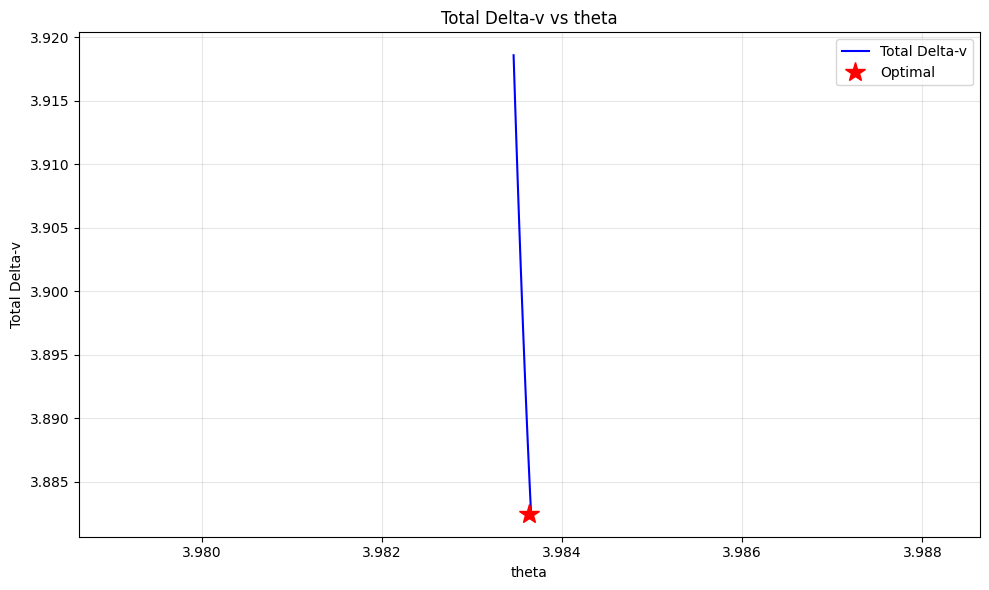

In [8]:
theta_sweep = run_sensitivity_1d('theta', theta_delta)

In [9]:
feasible_theta = theta_sweep.dropna(subset=['total_delta_v'])
max_theta = feasible_theta['theta'].max()
min_theta = feasible_theta['theta'].min()
print(f"Theta range: {max_theta - min_theta:.5f}")

Theta range: 0.00019


### Delta_v

Computing delta_v sweep...
Performing grid search with 1 x 5001 x 1 x 1 = 5001 grid points...
Iteration: 2039/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=-0.24 km, Total Delta_v=4.87 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=-0.24 km
Iteration: 2502/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.53 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.53 km

Found 2 feasible solutions.
  min Δv = 3.885171,  dist to LMO = 1.389511e-06


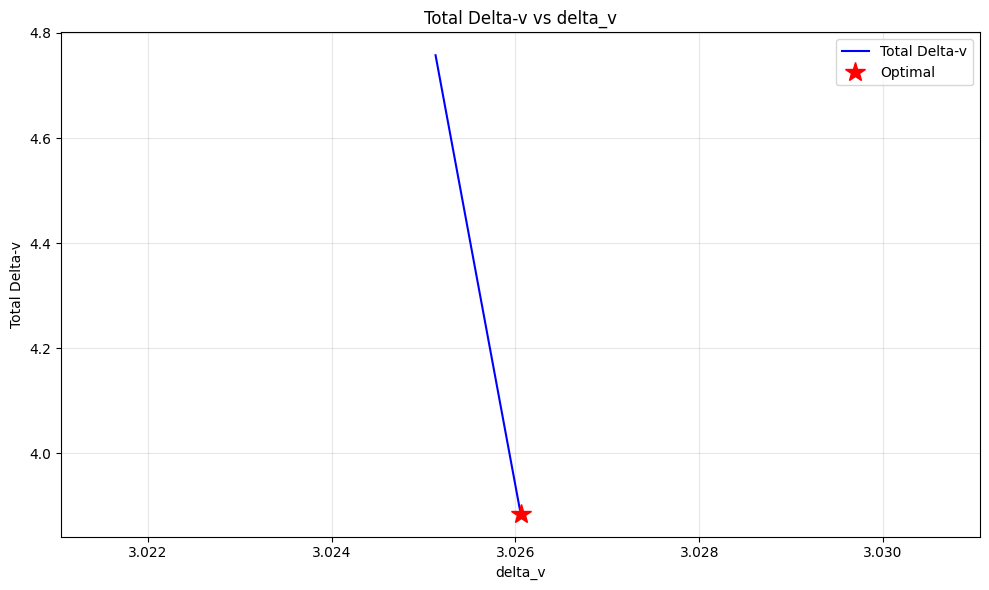

In [10]:
delta_v_sweep = run_sensitivity_1d('delta_v', delta_v_delta)

In [11]:
feasible_delta_v = delta_v_sweep.dropna(subset=['total_delta_v'])
max_delta_v = feasible_delta_v['delta_v'].max()
min_delta_v = feasible_delta_v['delta_v'].min()
print(f"Delta_v range: {max_delta_v - min_delta_v:.5f}")

Delta_v range: 0.00093


### Alpha

Computing delta_v_angle sweep...
Performing grid search with 1 x 1 x 5001 x 1 = 5001 grid points...
Iteration: 2501/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=1.05 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=1.05 km
Iteration: 2502/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.53 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.53 km
Iteration: 2503/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.02 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.02 km
Iteration: 2504/5001
Grid point satisfies con

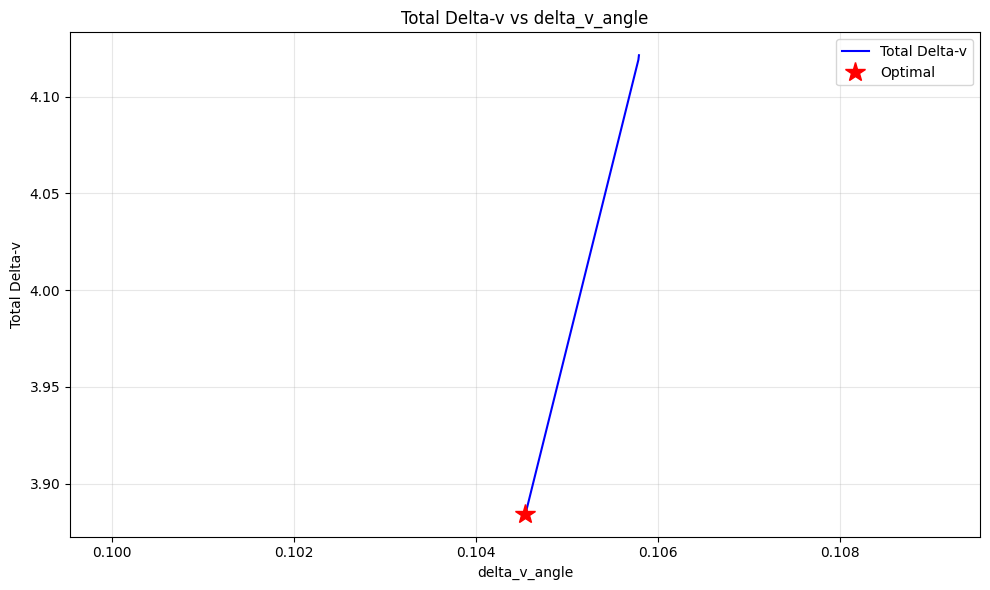

In [12]:
alpha_sweep = run_sensitivity_1d('delta_v_angle', delta_v_angle_delta)

In [13]:
feasible_delta_v_angle = alpha_sweep.dropna(subset=['total_delta_v'])
max_delta_v_angle = feasible_delta_v_angle['delta_v_angle'].max()
min_delta_v_angle = feasible_delta_v_angle['delta_v_angle'].min()
print(f"Delta_v_angle range: {max_delta_v_angle - min_delta_v_angle:.5f}")

Delta_v_angle range: 0.00125


### ToF

Computing tof sweep...
Performing grid search with 1 x 1 x 1 x 5001 = 5001 grid points...
Iteration: 2162/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.99 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.99 km
Iteration: 2163/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.80 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.80 km
Iteration: 2164/5001
Grid point satisfies constraint: Theta=3.98 rad, Delta_v=3.03, Delta_v_angle=0.10 rad, TOF=0.77 s => Distance to LMO=0.62 km, Total Delta_v=3.98 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.98 rad, Delta_v_angle=0.10 rad, TOF=0.77 s, Distance to LMO=0.62 km
Iteration: 2165/5001
Grid point satisfies constraint: T

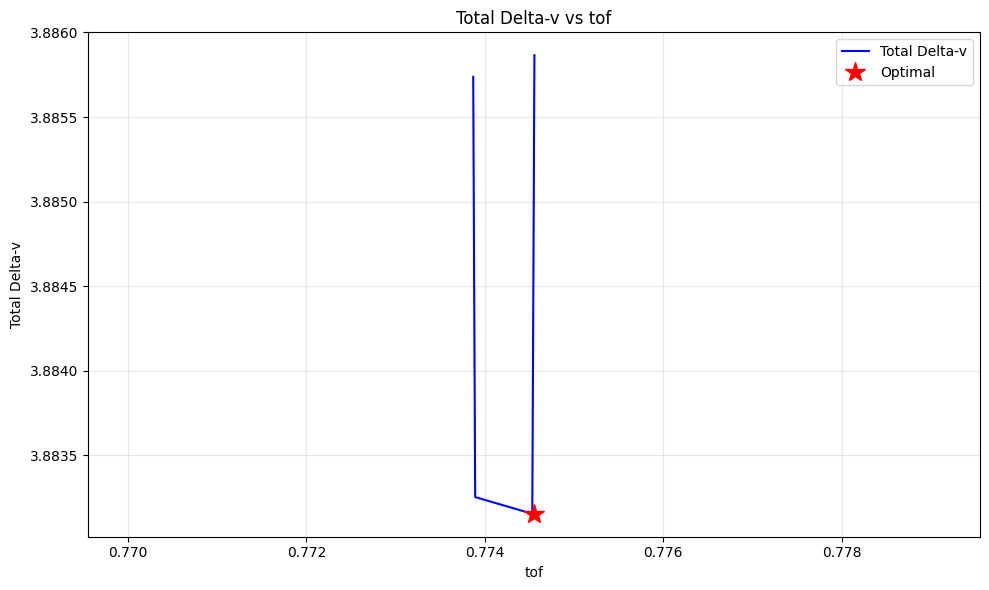

In [14]:
tof_sweep = run_sensitivity_1d('tof', tof_delta)

In [15]:
feasible_tof = tof_sweep.dropna(subset=['total_delta_v'])
max_tof = feasible_tof['tof'].max()
min_tof = feasible_tof['tof'].min()
print(f"TOF range: {max_tof - min_tof:.5f}")

TOF range: 0.00069
